# **Problem Description**
The dataset addresses the complex problem of commercial flight delays and operational performance within the U.S. aviation system. Specifically, it provides the historical data
necessary to understand, categorize, and predict flight arrival delays based on known pre-departure factors like schedules, routes, and airline information.Ultimately, the core problem is transforming millions of raw U.S. domestic flight records into actionable predictive models that can foresee delays safely before a plane departs, without relying on post-departure "leaked" data.

# **Problem Statement**
# **Objective**
The primary objective of this project is to develop a machine learning model capable of accurately determine the flight arrival delays entitled as On-time if the arrival delay is inferior of 15 minutes, short-delay if 15-30 minutes and long-delay if 30+ minutes. This will serve as a very usefull tool for all the airports world-wide.
## Approach:

1. **Data Preprocessing**: Conduct thorough data preprocessing steps, including handling missing values, encoding categorical variables, and scaling numerical features, to prepare the dataset for model training.

2. **Model Selection**: Explore various machine learning algorithms suitable for multiclass classification tasks, such as decision trees, random forests, support vector machines, and neural networks. Evaluate the performance of different models using appropriate evaluation metrics and cross-validation techniques.

3. **Feature Engineering**: Experiment with feature engineering techniques to extract meaningful insights from the environmental features and enhance the predictive power of the model. This may involve creating new features, transforming existing features, or selecting subsets of features based on their importance.

4. **Model Training and Evaluation**: Train the selected machine learning model on the preprocessed dataset and evaluate its performance using validation datasets or cross-validation methods. Fine-tune hyperparameters to optimize the model's performance and generalize well to unseen data.

5. **Interpretation and Insights**: Interpret the trained model to understand how different environmental features contribute to predicting forest cover types. Extract insights from the model's predictions to inform forest management decisions, conservation strategies, and land-use planning efforts.

## Success Criteria:

The success of the predictive models will be evaluated based on their ability to accurately forecast flight arrival delays and categorize delay severity on unseen flight data, strictly adhering to the requirement of preventing data leakage. Key performance metrics—such as Root Mean Square Error (RMSE) and Mean Absolute Error (MAE) for the regression tasks , alongside accuracy, precision, recall, and F1-score for the classification tasks —will be used to assess the models' performance against baseline benchmarks and evaluate the different algorithmic approaches (from the custom-built KNN to deep learning models).By addressing these objectives and following a systematic, six-phase data analytics lifecycle , the goal is to build reliable, interpretable predictive models and uncover operational patterns. Ultimately, these insights aim to contribute to more effective airline scheduling, proactive airport traffic management, and a better understanding of the root causes behind systemic flight delays.


# **Real world/Business Objective and Constraints**
## Objectives
1. **Airline Operations and Scheduling Optimization**: The primary objective is to develop robust predictive models that accurately forecast arrival delay duration and categorize delay severity (On-time, Short delay, Long delay) based on pre-departure features. This model can assist airlines in optimizing flight schedules, improving turnaround times, and reducing the heavy operational costs associated with unexpected delays
2. **Airport Resource and Traffic Management**: The project aims to identify underlying patterns in operational performance by clustering airports based on traffic characteristics and delay behaviors, as well as clustering airlines based on punctuality and route profiles. This information is valuable for airport authorities and air traffic controllers to anticipate congestion, allocate gate resources efficiently, and manage the National Airspace System.
3. **Passenger Experience Enhancement**: The predictive model and subsequent analysis can contribute to a more transparent travel experience. By reliably predicting delays before departure and understanding the statistical impact of factors like weather or carrier operations, airlines can proactively communicate with passengers, minimizing frustration and improving overall customer satisfaction

## Constraints

1. **Strict Data Leakage Prevention**: Ensuring the validity and fairness of the predictive models is the most critical constraint. It is imperative to strictly exclude variables that "leak" post-departure or future information into the model, such as actual departure times (DEP_TIME), taxi times (TAXI_OUT, TAXI_IN), and specific delay causes (DELAY_DUE_CARRIER, etc.)
2. **Data Quality and Contextual Filtering**: Ensuring the quality of the dataset is essential for model development. It is crucial to address missing values and apply domain-specific filtering, such as removing cancelled or diverted flights from the primary prediction tasks, as they do not possess meaningful arrival delay values.
3. **Interpretability and Explainability**: While maximizing prediction accuracy (using models ranging from custom KNNs to Deep Learning) is important, maintaining model interpretability is critical for gaining stakeholders' trust. The analysis must provide transparent explanations—supported by statistical hypothesis testing—of how different operational and environmental factors truly influence flight delays.
4. **Generalizability Across the U.S. Aviation System**: The models must generalize well across the vast U.S. domestic aviation network, covering millions of flight records over multiple years (2019-2023). It is essential to evaluate performance across different airlines, geographic routes, seasons, and varying environmental conditions to ensure systemic robustness and reliability.

By addressing these objectives and constraints, the predictive model aims to contribute to effective airline management, proactive airport resource allocation, and a deeper understanding of airspace congestion, ultimately promoting a more efficient and reliable commercial aviation network.

In [1]:
import sys
import os

# Tell Python to look in the folder one level up (03_codigo) for imports
sys.path.append(os.path.abspath(''))

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
import numpy as np

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.manifold import TSNE

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor # predict a continuous scale of numbers, better than classifier who just understands labels
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns

import itertools
from itertools import combinations_with_replacement

from scipy.stats import f_oneway, kruskal, ttest_ind

import pickle
import umap
#pip install mrmr_selection
import math

import warnings
warnings.filterwarnings("ignore")

# Import the specific classes from their respective folders and files
from DataCleaning.DataCleaning import DataCleaning
from DataLoader.DataLoader import DataLoader
from DataPreprocessing.DataPreprocessing import DataPreprocessing
from FeatureEngineering.FeatureEngineering import FeatureEngineering
from EDA.EDA import EDA
from FlightDimensionalityReduction.FlightDimensionalityReduction import FlightDimensionalityReduction
from DataVisualization.DataVisualization import DataVisualization
from HypothesisTesting.HypothesisTesting import HypothesisTesting

C:\Users\omarc\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_loader = DataLoader("../data/flights_sample_3m.csv")
# Shows the before and after of the Data Analysis
print("\n\nBefore data preprocessing")
print("Training data shape:", data_loader.data_train.shape)
print("Training labels shape:", data_loader.labels_train.shape)
print("Testing data shape:", data_loader.data_test.shape)
print("Testing labels shape:", data_loader.labels_test.shape)

Original shape: (3000000, 32)
Shape after removing cancelled/diverted: (2913804, 32)
Data loaded and split successfully.


Before data preprocessing
Training data shape: (2331043, 31)
Training labels shape: (2331043,)
Testing data shape: (582761, 31)
Testing labels shape: (582761,)


In [3]:
data_cleaner = DataCleaning(data_loader)
data_cleaner.remove_leakage()
data_cleaner.remove_duplicates()
data_cleaner.handle_missing_values()
data_cleaner.remove_outliers()
print("\n\nAfter data preprocessing")
print("Training data shape:", data_loader.data_train.shape)
print("Training labels shape:", data_loader.labels_train.shape)
print("Testing data shape:", data_loader.data_test.shape)
print("Testing labels shape:", data_loader.labels_test.shape)

Removed 16 leakage columns.
Duplicate rows removed from training data.
Missing values handled using strategy: drop
Outliers removed from the dataset.


After data preprocessing
Training data shape: (2087026, 15)
Training labels shape: (2087026,)
Testing data shape: (582759, 15)
Testing labels shape: (582759,)


In [4]:
# 1. Aplicar a função aos dados de Treino e Teste
# Aqui assumimos que a variável da tua classe se chama 'preprocessor'
print("A processar Feature Engineering...")
fe = FeatureEngineering()
data_loader.data_train = fe.perform_feature_engineering(data_loader.data_train)
data_loader.data_test = fe.perform_feature_engineering(data_loader.data_test)

# 2. Definir a lista das colunas novas para filtrar a tabela
novas_colunas = [
    'FL_DATE','MONTH','IS_HOLIDAY_MONTH','DAY_OF_WEEK','IS_WEEKEND','SEASON','CRS_DEP_HOUR','TIME_OF_DAY','FLIGHT_TYPE','ROUTE','CRS_ARR_HOUR','PLANNED_SPEED'
]


# 3. Visualizar o resultado!
print("\n--- Novas Features (Primeiras 5 linhas do Treino) ---")
display(data_loader.data_train[novas_colunas].head())

A processar Feature Engineering...

--- Novas Features (Primeiras 5 linhas do Treino) ---


,FL_DATE,MONTH,IS_HOLIDAY_MONTH,DAY_OF_WEEK,IS_WEEKEND,SEASON,CRS_DEP_HOUR,TIME_OF_DAY,FLIGHT_TYPE,ROUTE,CRS_ARR_HOUR,PLANNED_SPEED
1075737,2019-03-26,3,0,1,0,2,5,0,0.0,ABQ_SLC,7,4.650900
397110,2019-06-01,6,0,5,1,3,10,1,1.0,LAS_DFW,15,6.472353
171803,2023-03-20,3,0,0,0,2,5,0,1.0,HPN_DTW,7,4.072548
1517003,2023-08-02,8,1,2,0,3,13,2,1.0,PBI_ATL,15,4.822966
700726,2022-12-17,12,1,5,1,1,10,1,0.0,IAH_DFW,12,2.036345


In [5]:
num_cols = ['CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'CRS_DEP_HOUR', 'CRS_ARR_HOUR', 'PLANNED_SPEED']
cat_cols = ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'SEASON', 'IS_HOLIDAY_MONTH', 'TIME_OF_DAY', 'FLIGHT_TYPE', 'ROUTE']

# 2. CHECKPOINT 1: Cleaned Data (Before encoding - for EDA & Hypothesis Testing)
import pickle
with open('data_loader_cleaned.pkl', 'wb') as f:
    pickle.dump(data_loader, f)
print("Saved Checkpoint 1: 'data_loader_cleaned.pkl' (Ready for EDA and Hypothesis Testing)")

Saved Checkpoint 1: 'data_loader_cleaned.pkl' (Ready for EDA and Hypothesis Testing)


In [6]:
# 3. APPLY PREPROCESSING (Scaling and One-Hot Encoding)
data_preprocessing = DataPreprocessing(data_loader, num_cols, cat_cols)
print("\n--- 3. After Data Preprocessing (Scaled & Encoded) ---")

# 4. CHECKPOINT 2: Preprocessed Data (for ML)
with open('data_loader_preprocessed.pkl', 'wb') as f:
    pickle.dump(data_loader, f)
print("Saved Checkpoint 2: 'data_loader_preprocessed.pkl'")

Categorical features ['AIRLINE_CODE', 'ORIGIN', 'DEST', 'MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'SEASON', 'IS_HOLIDAY_MONTH', 'TIME_OF_DAY', 'FLIGHT_TYPE', 'ROUTE'] encoded successfully.
Features normalized successfully.

--- 3. After Data Preprocessing (Scaled & Encoded) ---
Saved Checkpoint 2: 'data_loader_preprocessed.pkl'


In [7]:
# 5. Deserialize the preprocessed data to verify it loaded correctly
with open('data_loader_preprocessed.pkl', 'rb') as f:
    data_loader_loaded = pickle.load(f)

print("\n\nDeserialized Preprocessed Data Check:")
print("Training data shape:", data_loader_loaded.data_train.shape)
print("Training labels shape:", data_loader_loaded.labels_train.shape)
print("Testing data shape:", data_loader_loaded.data_test.shape)
print("Testing labels shape:", data_loader_loaded.labels_test.shape)



Deserialized Preprocessed Data Check:
Training data shape: (2087026, 26)
Training labels shape: (2087026,)
Testing data shape: (582759, 26)
Testing labels shape: (582759,)


# **Exploratory Data Analysis (EDA)**

Exploratory Data Analysis (EDA) Report:
--------------------------------------

Summary Statistics for train data:
                          FL_DATE  AIRLINE_CODE      DOT_CODE     FL_NUMBER  \
count                     2087026  2.087026e+06  2.087026e+06  2.087026e+06   
mean   2021-05-12 16:20:34.230911  5.325241e-01  1.997825e+04  2.559926e+03   
min           2019-01-01 00:00:00  0.000000e+00  1.939300e+04  1.000000e+00   
25%           2019-12-30 00:00:00  2.352941e-01  1.979000e+04  1.145000e+03   
50%           2021-07-02 00:00:00  6.470588e-01  1.997700e+04  2.238000e+03   
75%           2022-08-06 00:00:00  8.823529e-01  2.036800e+04  3.851000e+03   
max           2023-08-31 00:00:00  1.000000e+00  2.045200e+04  5.999000e+03   
std                           NaN  3.319392e-01  3.822764e+02  1.692582e+03   

             ORIGIN          DEST  CRS_DEP_TIME  CRS_ARR_TIME  \
count  2.087026e+06  2.087026e+06  2.087026e+06  2.087026e+06   
mean   4.840858e-01  4.824651e-01 -3.502622

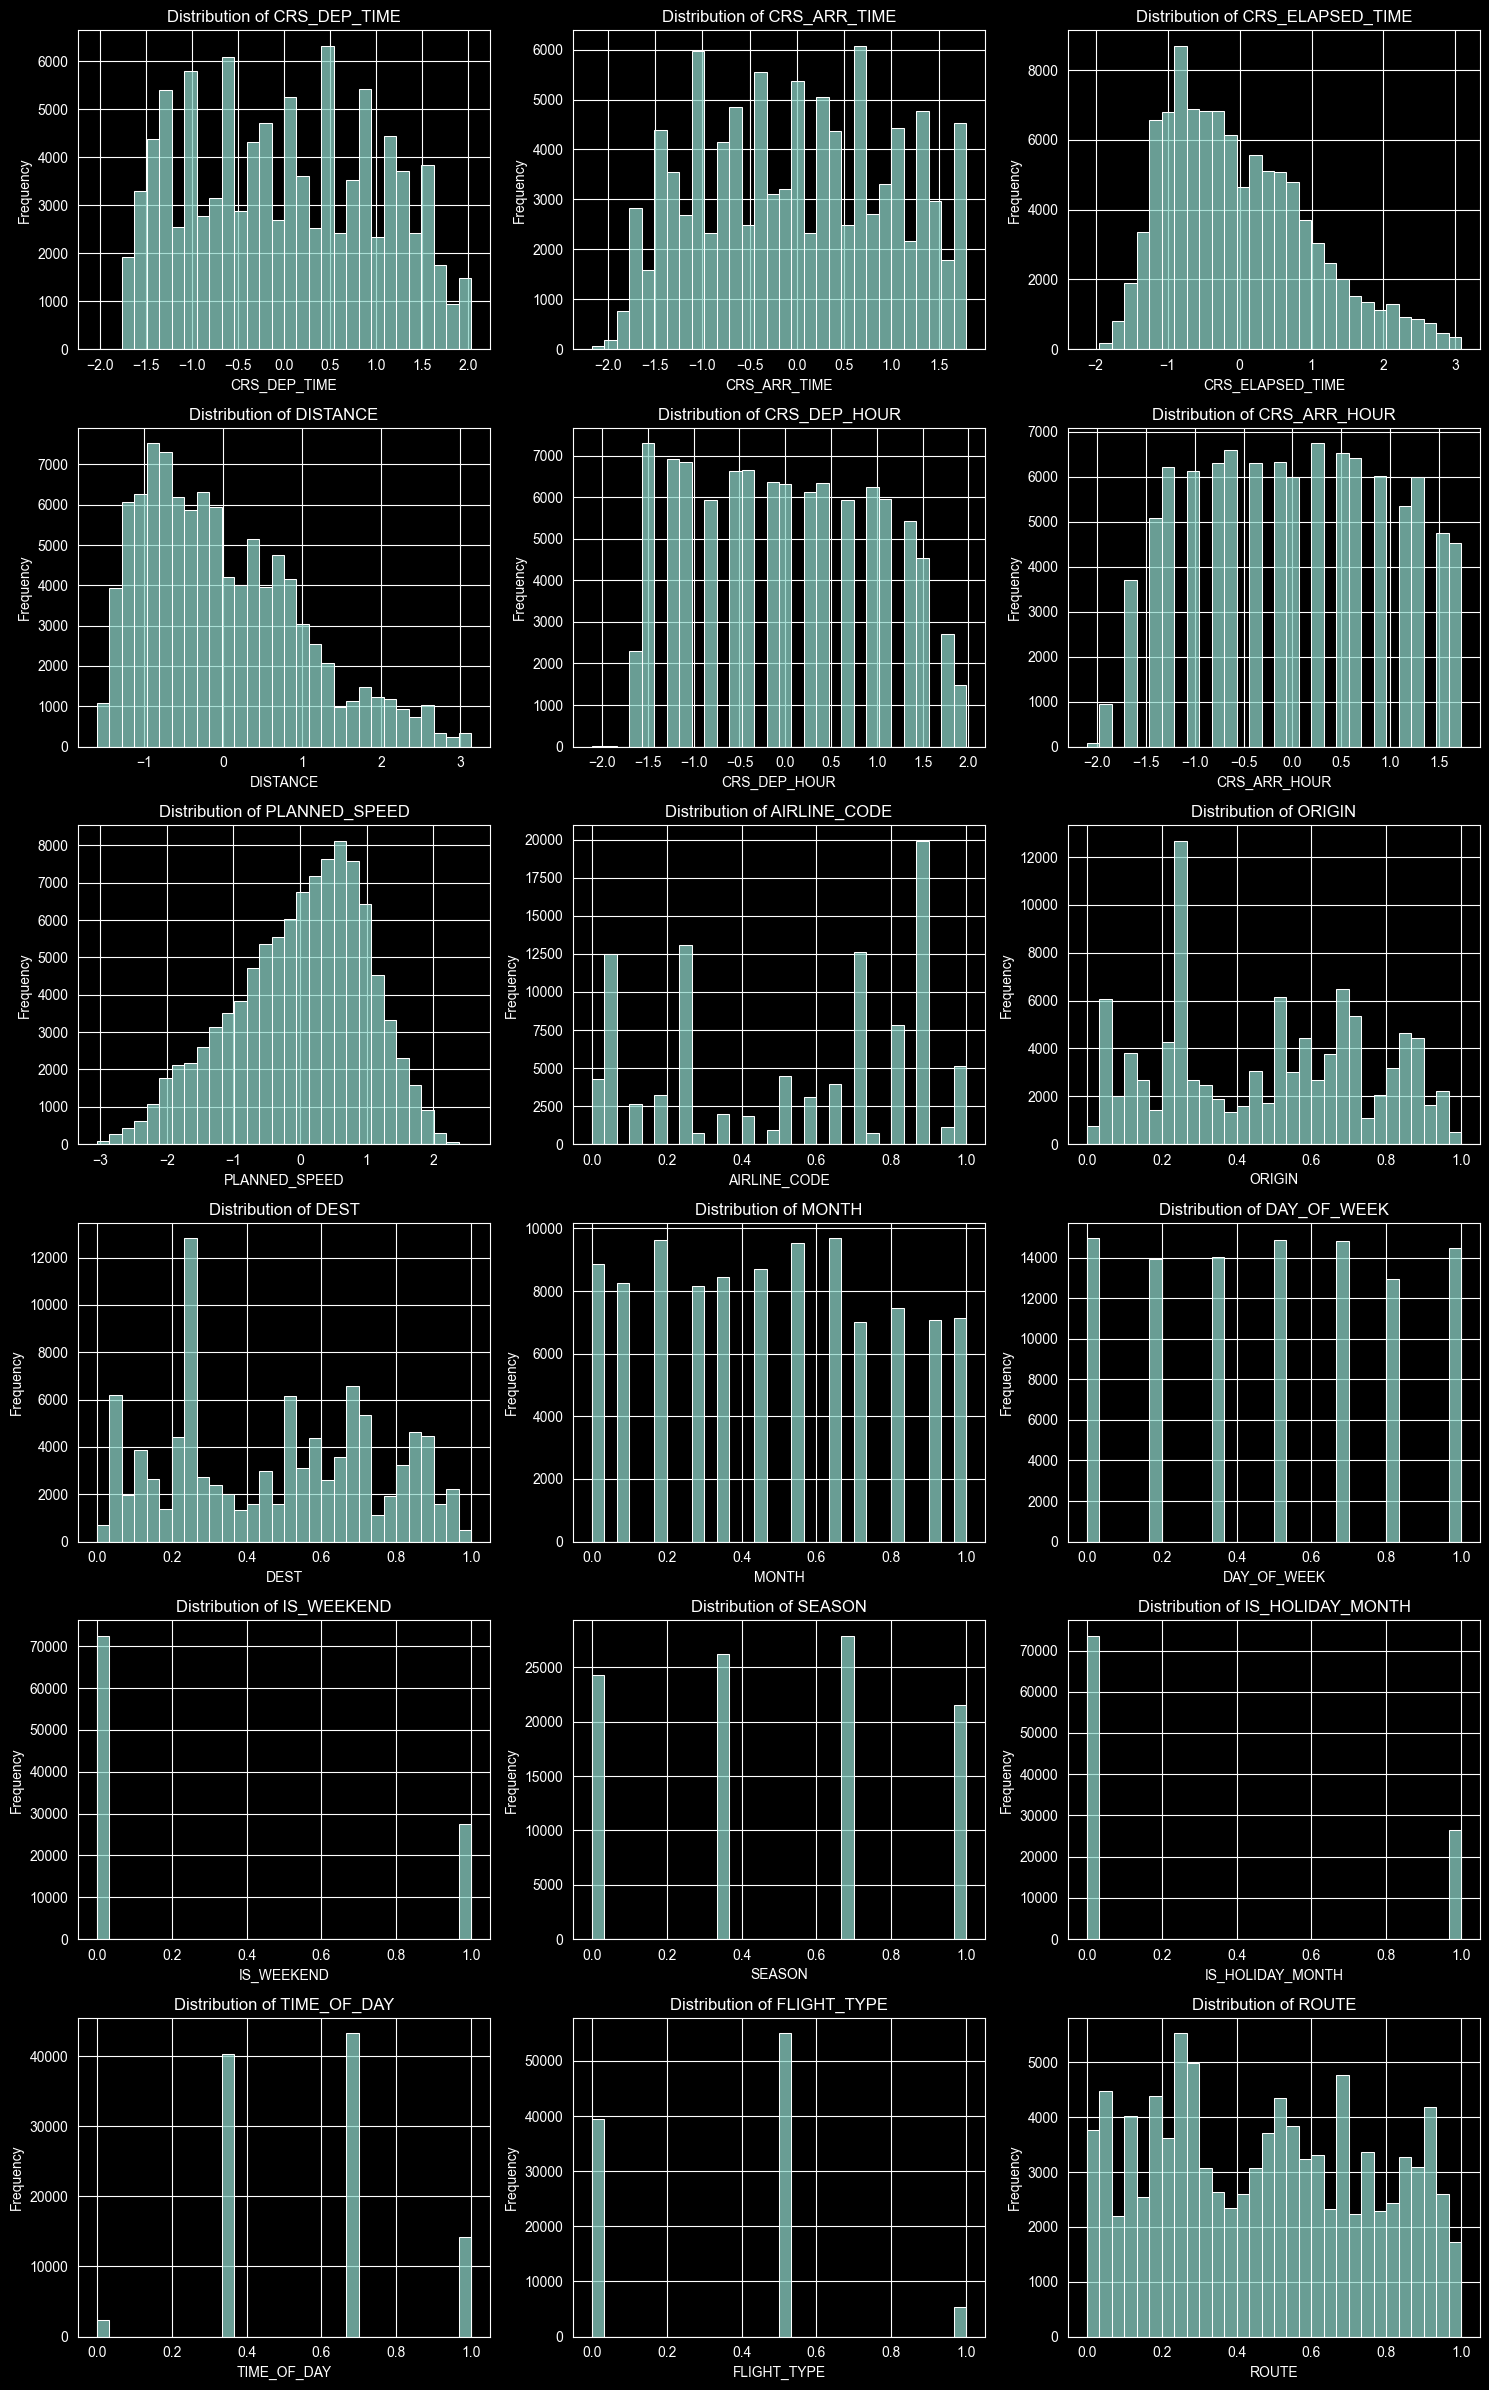


Correlation Analysis:


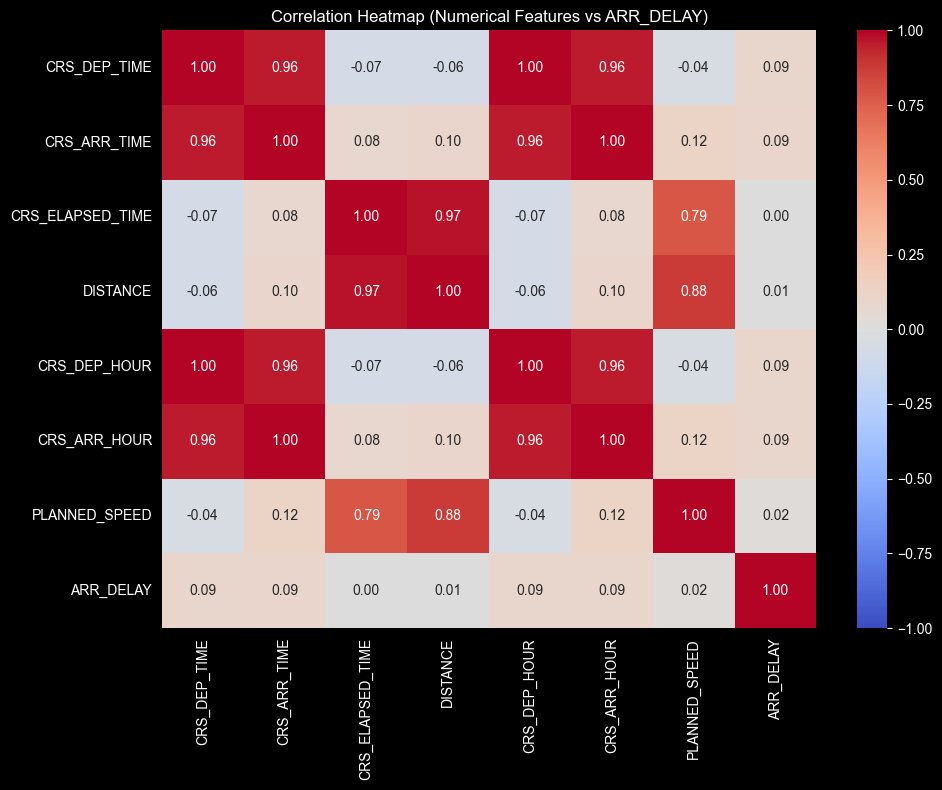


Feature Importance Analysis:
Sampling 50000 rows for feature importance to save time...


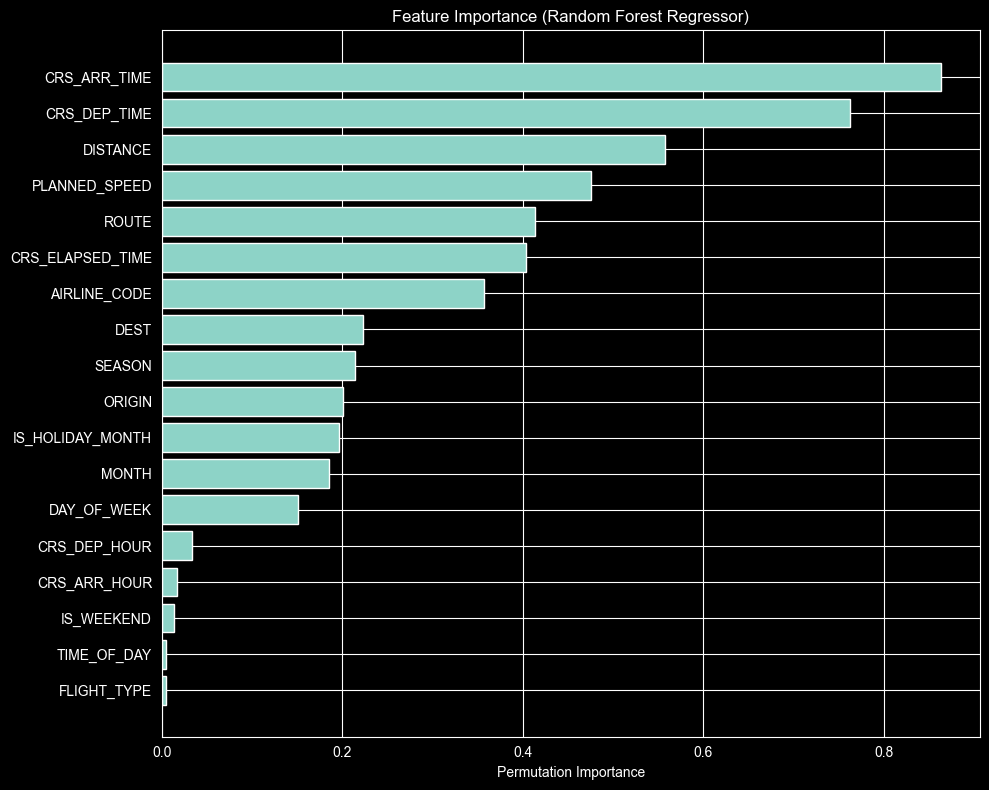

In [8]:
eda = EDA(data_loader,num_cols,cat_cols)
eda.perform_eda()

Data Visualization Plots:
Sampling 100000 rows for Boxplots to save time...


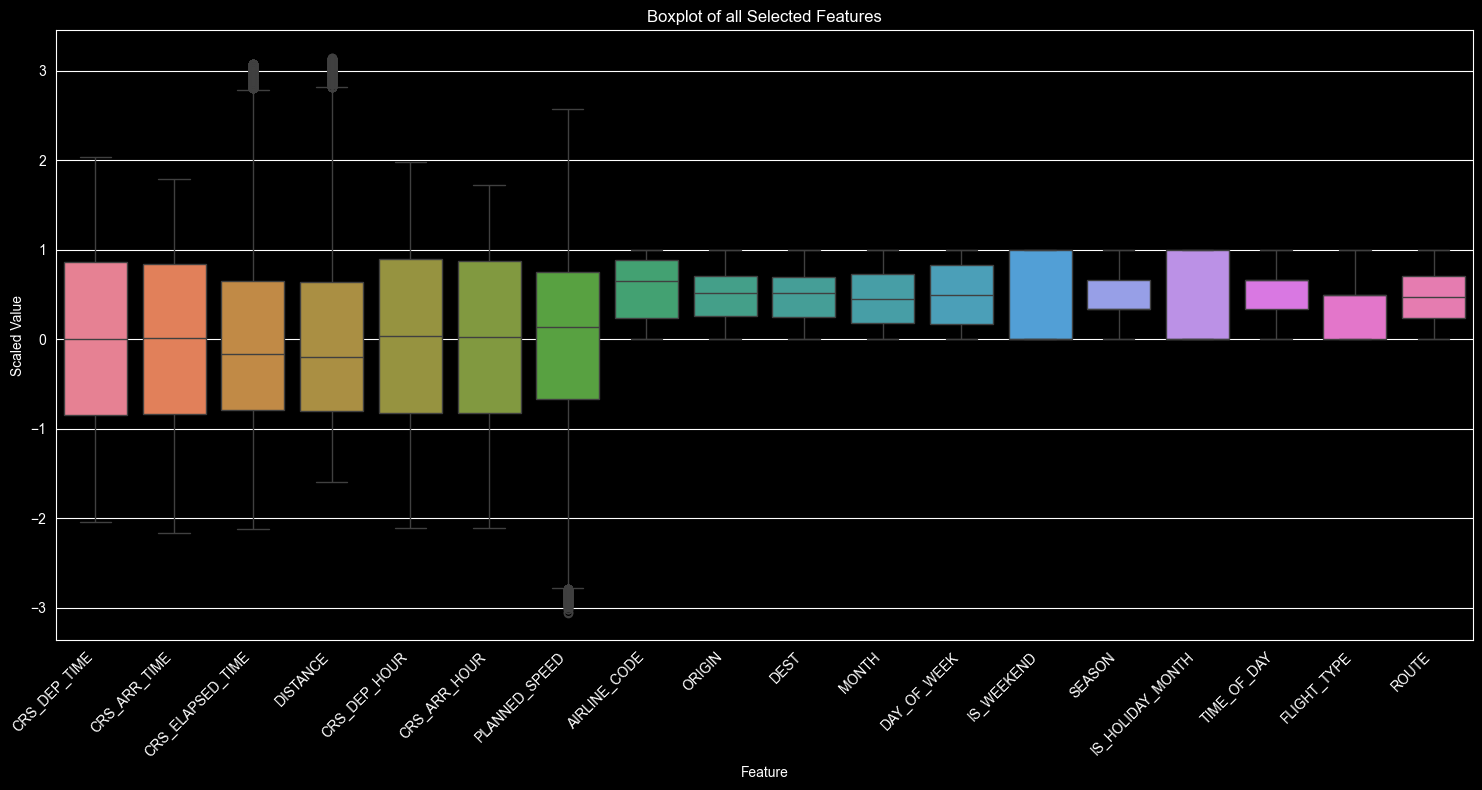

Sampling 10000 rows for Ridgeplots to prevent KDE memory crashes...


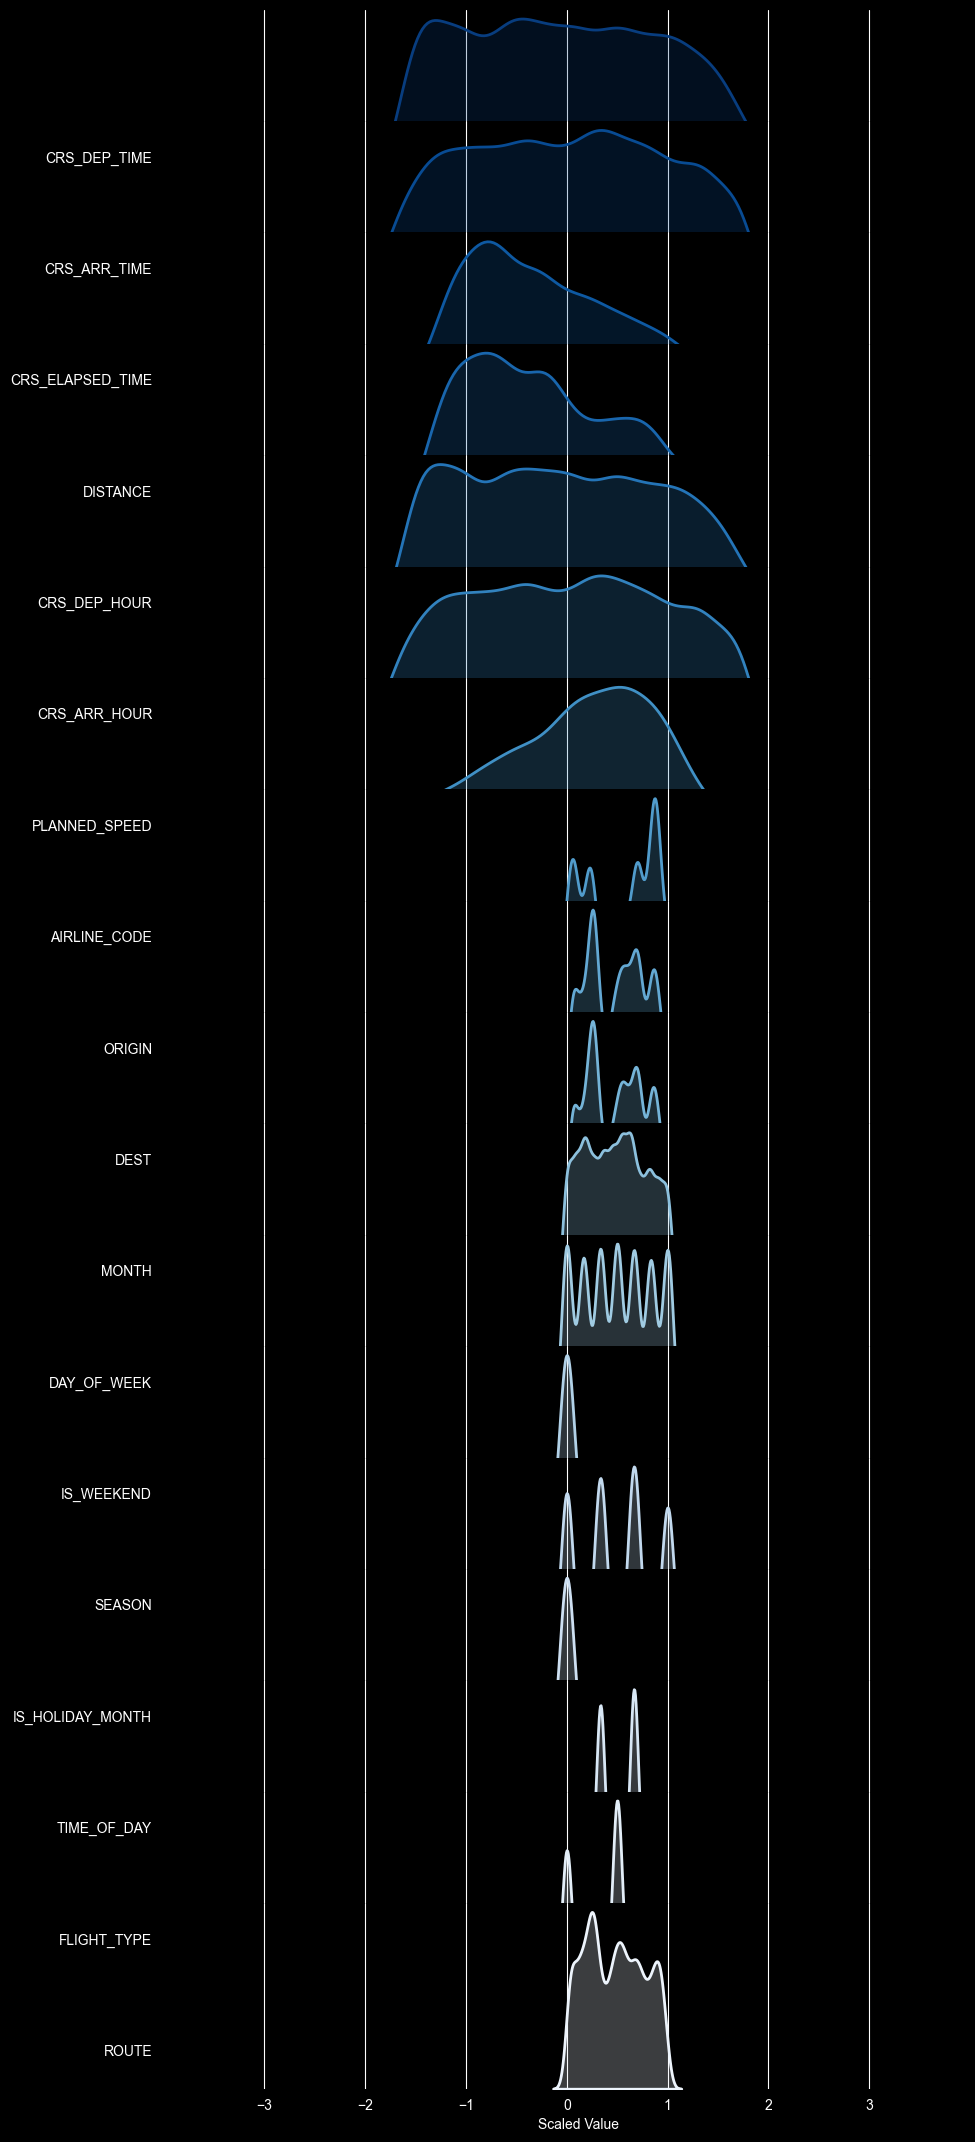

In [9]:
features_to_use = num_cols + cat_cols
datavisualization = DataVisualization(data_loader, features_to_use)
datavisualization.perform_visualization()

# **Dimensionality Reduction**


Sampling 10000 rows for dimensionality reduction...
Computing PCA (Linear Method)...


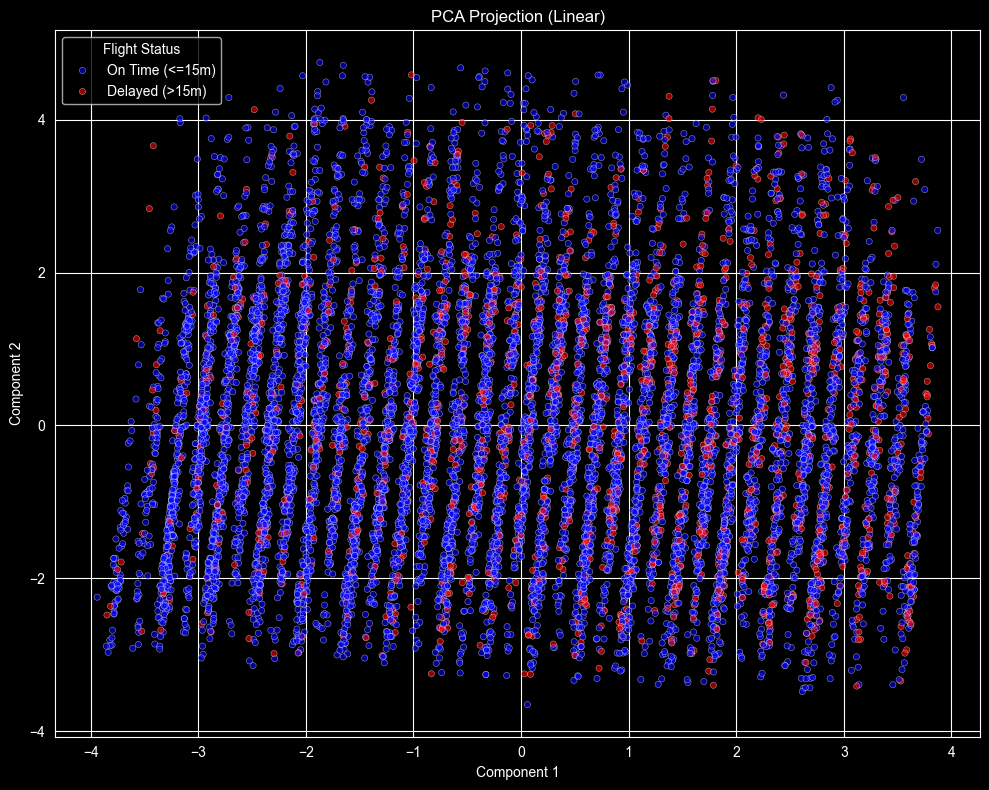

Computing UMAP (Non-Linear Method)...


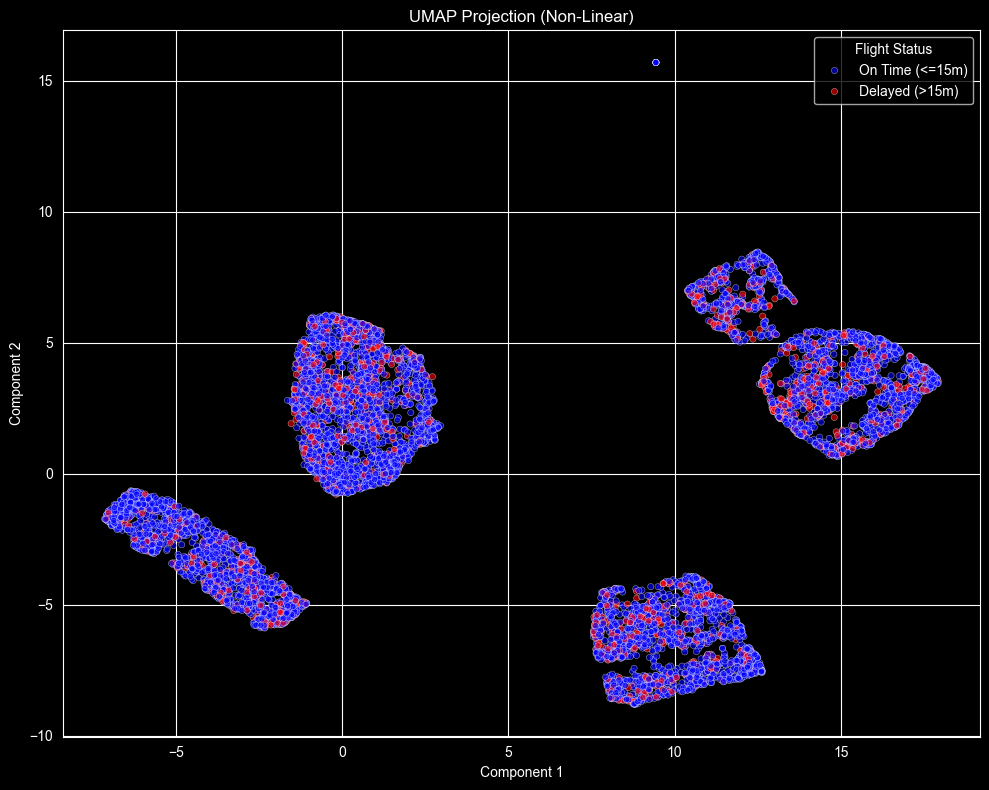

Generating UMAPs for 9 features...


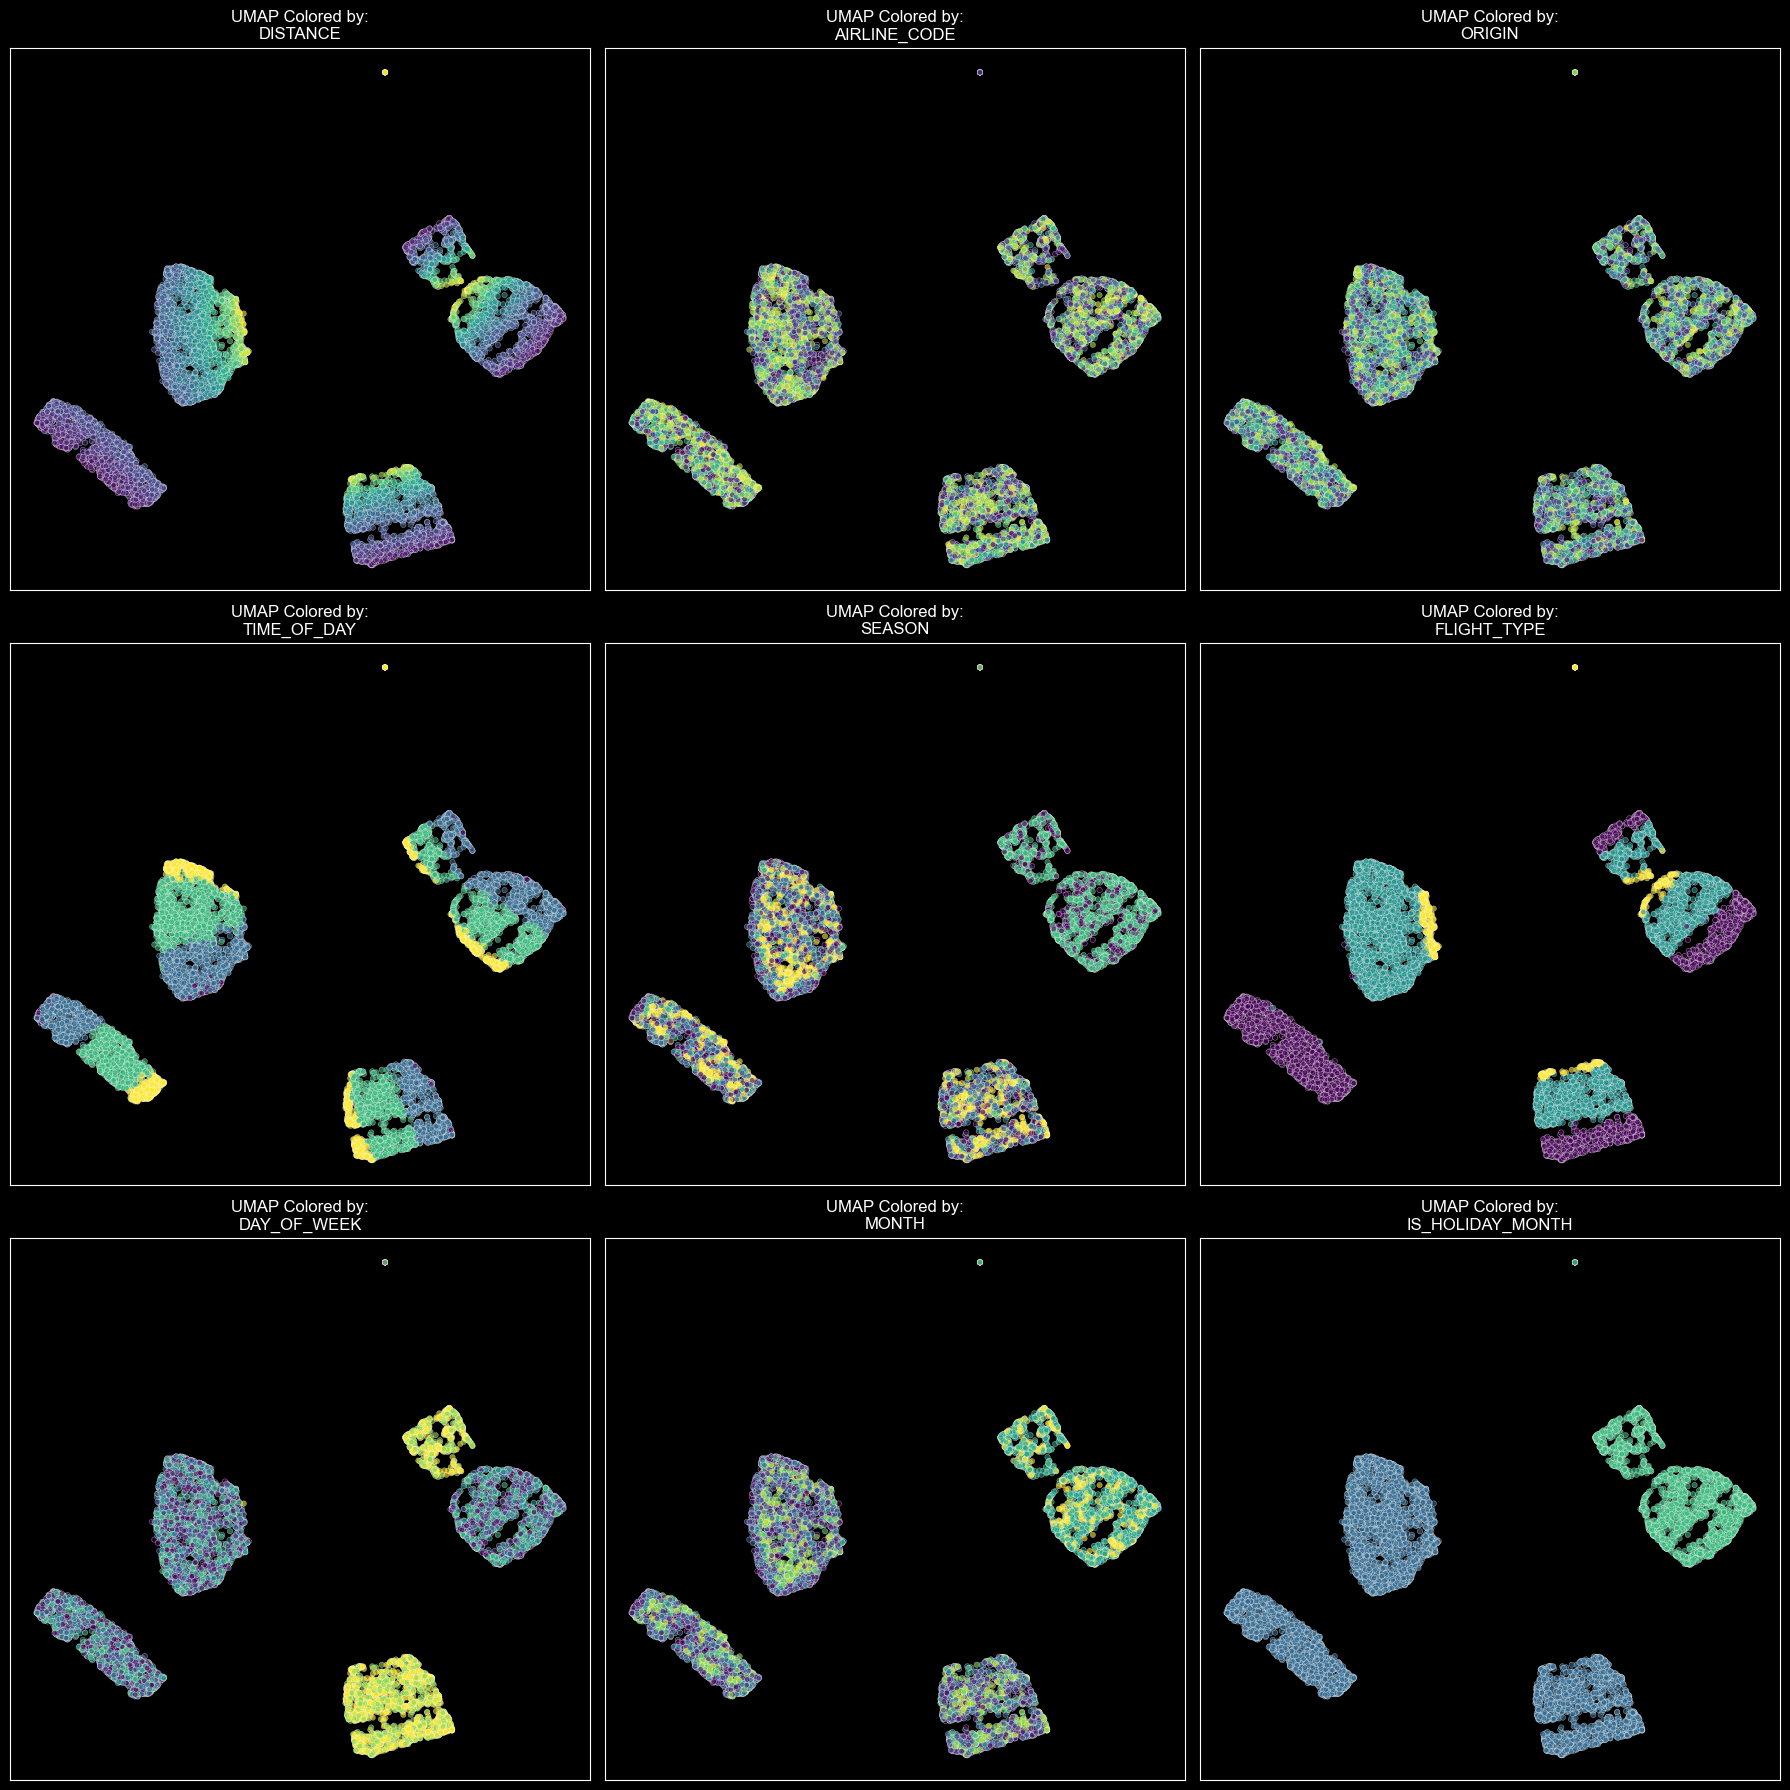

Computing t-SNE (Non-Linear Method)...


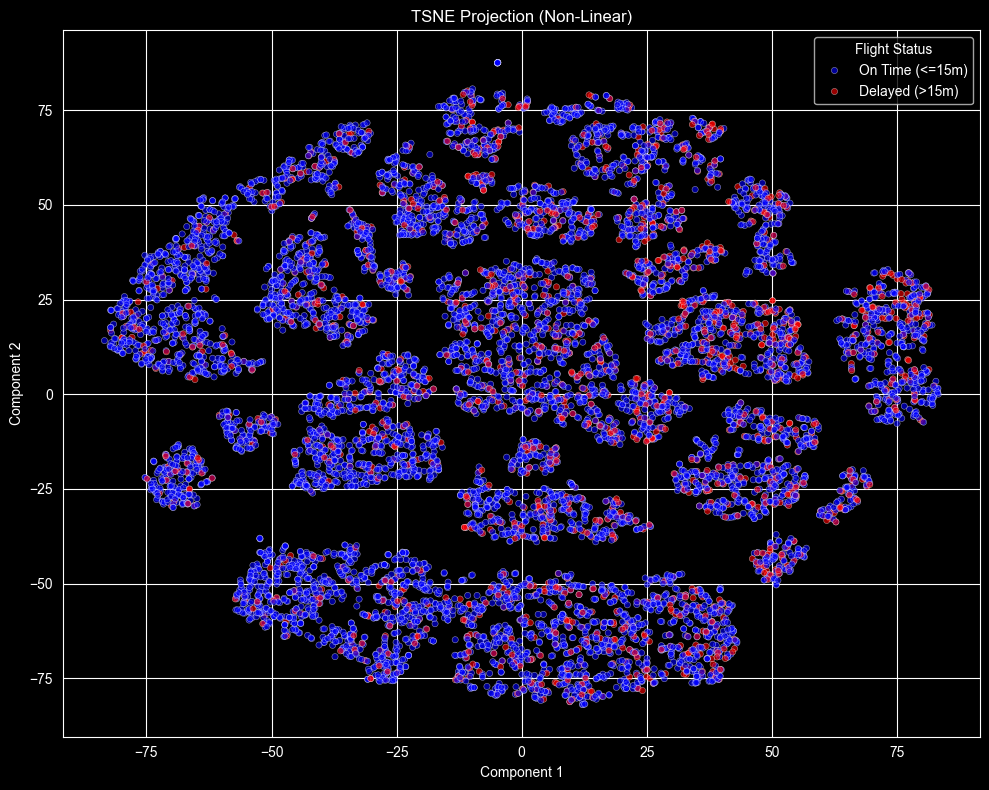

In [10]:
# 2. Initialize the class (it automatically samples the data)
dr = FlightDimensionalityReduction(data_loader, features_to_use)

# 3. Compute and plot PCA (Linear)
pca_proj = dr.compute_pca()
dr.plot_projection(pca_proj, 'PCA Projection (Linear)')

# 4. Compute and plot UMAP (Non-Linear)
umap_proj = dr.compute_umap()
dr.plot_projection(umap_proj, 'UMAP Projection (Non-Linear)')
# Assuming you already have umap_proj from the previous steps:
features_to_investigate = [
    'DISTANCE', 'AIRLINE_CODE', 'ORIGIN', 'TIME_OF_DAY',
    'SEASON', 'FLIGHT_TYPE', 'DAY_OF_WEEK', 'MONTH', 'IS_HOLIDAY_MONTH'
]
dr.analyze_umap_clusters(umap_proj,features_to_investigate)

tsne_proj = dr.compute_tsne()
dr.plot_projection(tsne_proj, 'TSNE Projection (Non-Linear)')


# Statistical Analysis

In [11]:
with open('data_loader_cleaned.pkl', 'rb') as f:
    data_loader_for_testing = pickle.load(f)

# 2. Run the Tests!
ht = HypothesisTesting(data_loader_for_testing)
ht.run_all_tests()

--- Hypothesis Testing Results (Target: ARR_DELAY) ---

>>> T-TESTS (Comparing 2 Groups) <<<
Feature: IS_WEEKEND         | p-value: 6.8890e-06 | Significant: True
Feature: IS_HOLIDAY_MONTH   | p-value: 0.0000e+00 | Significant: True

>>> KRUSKAL-WALLIS TESTS (Comparing 3+ Groups) <<<
Feature: TIME_OF_DAY        | p-value: 0.0000e+00 | Significant: True
Feature: SEASON             | p-value: 0.0000e+00 | Significant: True
Feature: FLIGHT_TYPE        | p-value: 5.0066e-180 | Significant: True
Feature: DAY_OF_WEEK        | p-value: 0.0000e+00 | Significant: True
Feature: MONTH              | p-value: 0.0000e+00 | Significant: True
